<a href="https://www.kaggle.com/code/matheuslatorrecavini/heptapod-b-generator-text2logogram?scriptVersionId=248865746" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Heptapod-B Generator

## Introduction

For those who are unfamiliar with what this notebook might be about, **Heptapod-B** is the name of the written language spoken by the aliens named *Heptapods*, in the movie **Arrival (2016)**.

The language is described as being non-linear, time-independent and semasiographic, meaning the logograms represent concepts and have no connection to phonems of the spoken form.

If you want to know a little more about how the language is structured, and what are its inconsistences (since it is a fictional work, not a real language), I strongly recommend watching [this video from 'Language & Film'](https://www.youtube.com/watch?v=me9uliPVqeU). It might provide some insight on some ideas used for data augmentation and evaluating results, as well as on the limitations of this project (again, keep in mind it is a fictional language, so results can only go as far as its creation goes).

In the movie, the linguist Louise is tasked with deciphering an alien language in order to establish communication with the Heptapods. Her approach involves presenting concepts — such as objects, actions, abstract ideas, and full sentences — and observing the corresponding logograms produced by the aliens. Over time, she builds a partial lexicon and begins to understand the structure of their written language, identifying recurring patterns and possible morphemes. This handcrafted process enables her not only to interpret, but also to construct new logograms.

![Louise interacting with Heptapods ](https://res.cloudinary.com/jerrick/image/upload/d_642250b563292b35f27461a7.png,f_jpg,fl_progressive,q_auto,w_1024/63b663b7b0af28001c82fcb3.jpg)

While effective in the film, this method is fundamentally manual and relies heavily on the linguist's own insight to uncover the language’s structure and generative principles.

But what if we could automate that process?

In the era of large language models, GPTs, and powerful image generation tools, it's natural to wonder: _Could a model be trained to learn the Heptapod-B language — not by decoding it manually — but by learning directly from pairs of English sentences and their corresponding logograms, as Louise might have collected?_

This project explores that idea: to build a multimodal system capable of understanding the latent structure of Heptapod-B, and generate novel logograms directly from English sentences made of the vocabulary presented in training.

In short: let’s teach a machine to think like Louise.

## The Dataset

### Original Source

Since the language is fictional, the dataset for Heptapod-English correspondences is fairly small and restrict to some sentences and vocabulary used in the movie or developed in early experimental stages, which might be a problem as training language models usually requires lots of data. But I tried to do the best with what I had.

So, the dataset I used for training my model is the one avaiable at [this GitHub repo](https://github.com/WolframResearch/Arrival-Movie-Live-Coding/tree/master/ScriptLogoJpegs), which consists of 38 images at 3300x3300 resolution, named with the meaning of the logogram. This "dictionary" was created by some people from Wolfram who worked in the development of a software for the movie, so it might be considered (to a certain level) an official source of information.

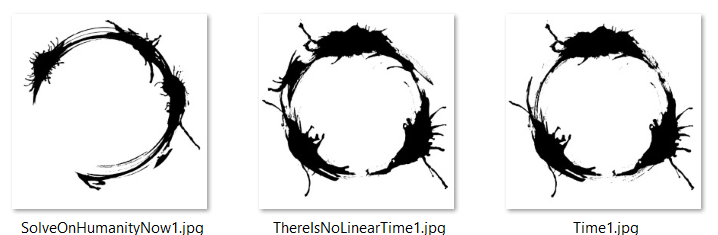


### Data Augmentation and Preprocessing
Now, 38 pairs of Logograms-Sentences is unfortunately a very small amount of data. In order to try to improve that a little bit, I applied two manual techniques for data augmentation:

1. Merging morphems with known meanings together to create new meaningful sentences. For exemple: joining "Heptapod" and "Walk" to create "Heptapod walk"

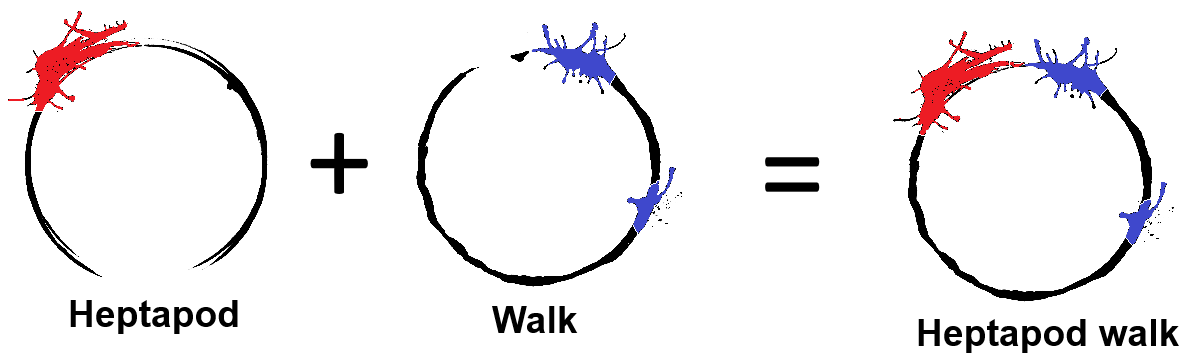
   
   
2. Isolating morphems from sentences to create a logogram of an isolated concept. For example: removing the morphem for "Abbott" from "Abbott is dead" to create a logogram for "is (to be) dead"

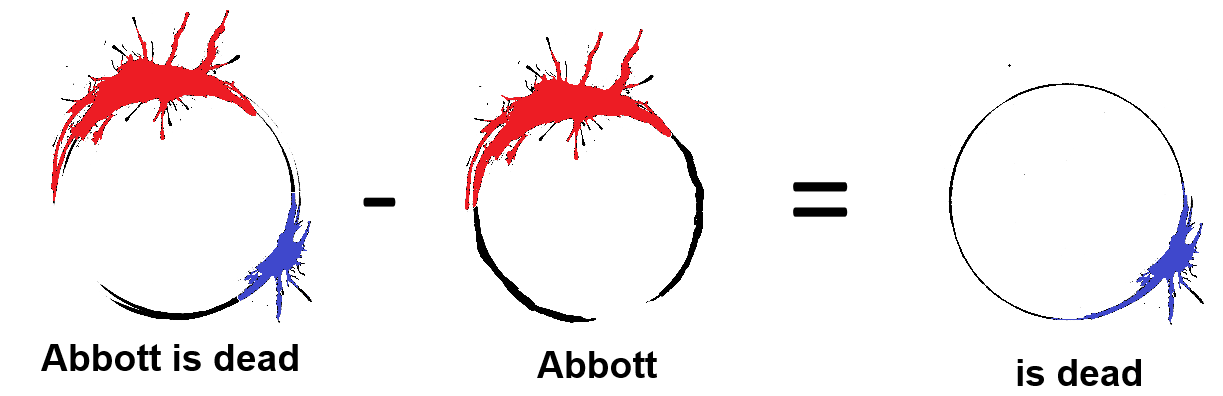
  

> **I believe it is important to make a disclaimer at this point:** this _operations_ are basically what we expect the final model to be able to perform - creating new logograms using patterns from the learned ones. So is it counterintuitive to do them manually for training? Perhaps. However, as I said before, I needed more training data. So I went through the process of making a small amount of this by hand, to train a model that can (hopefully) do this by itself later.

Another step for data augmentation was to perform image trasformations on the logograms to introduce some variation. For that, I created 100 variations for each image (original + 99), with the following transformations:

* Making the image binary (black and white)
* Resizing the image to 224x224 (ResNet standard, even though I am not using it)
* Applying a random rotation of up to 10º
* Applying a random translation of up to 5% in each dimension
* Applying a random scaling of up to $\pm$5%

After doing all this, I ended up with a dataset of 49 logogram-sentence correspondences, with each logogram having 100 224x224 image variations, totalizing 4900 images to train the model on. This dataset can be found attached on this Kaggle workspace. The `captions.txt` file has the captions for each differente logogram, and matching them to all the images is further done in code:

```
000.png | Abbot is dead
001.png | Abbot
002.png | Abbot chooses save humanity
003.png | Abbot chooses save Ian&Louise
004.png | Abbot solve
005.png | Before and After 
```

The dataset can than be loaded using the following code:


In [1]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os

class TextToImageDataset(Dataset):
    def __init__(self, image_dir, captions_file, transform=None):
        self.image_dir = image_dir # Path for the images on the dataset
        self.transform = transform
        self.pairs = [] # Array to store (image, sentence) pairs

        with open(captions_file, "r") as f:
            for line in f:
                idx, caption = line.strip().split("|")
                idx = idx.strip().split(".")[0]
                caption = caption.strip()
                for i in range(100):
                    img_file = f"{(int(idx)*100 + i):04d}.png" # Get the image number by doing idx*100 + i 
                    self.pairs.append((caption, img_file))     # Apply the same caption for every variation of the same logogram

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        text, img_file = self.pairs[idx]
        image = Image.open(os.path.join(self.image_dir, img_file)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return text, image #item = (text, image)


In [2]:
# Make sure that images are resized to 224x224 and convert to tensor
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

base_dir = "/kaggle/input/heptapod-dataset/dataset/"

dataset = TextToImageDataset(image_dir=base_dir+"images",captions_file=base_dir+"captions.txt", transform=transform)

We can check an example of a datapair loaded to dataset:

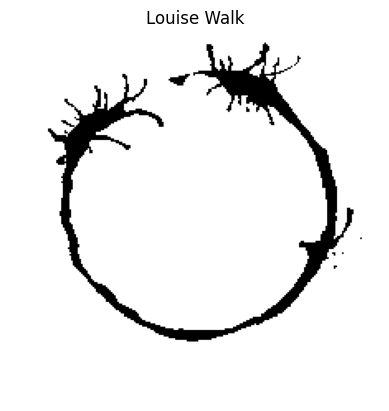

In [3]:
import matplotlib.pyplot as plt
from random import randint

def show_tensor_image(t, text = ""):
    t = t.squeeze().detach().cpu()
    if t.shape[0] == 1:
        plt.imshow(t[0], cmap="gray", title=title)
    else:
        plt.imshow(t.permute(1, 2, 0))  # [C, H, W] → [H, W, C]
    if text !="":
        plt.title(text)
    plt.axis("off")

ex_caption, ex_img =  dataset[randint(0,4900)]
show_tensor_image(ex_img, ex_caption)

## $\beta$-VAE: Learning the structures of logograms

As previously explained, the logograms are composed by morphems, which have a particular geometry, trace and other visual characteristics.

The first goal for a model that tries to generate logograms would be, then, to understand this geometrical features. For that, I trained a **$\beta$-Variational Autoencoder ($\beta$-VAE)**, whose goal is to learn a latent representation for the logograms that is way lower dimensional than the plain images (which are 224x225 = 50176 dimensional), and to be capable of reconstructing the logogram from the low-dimensional representation. The $\beta$-VAE differs from a traditional VAE in the sense that a loss parameter $\beta$ tries to force the dimensions of the learned representations to be independent, what might be desirable for this application, meaning each dimension encodes a particular feature of the logograms.

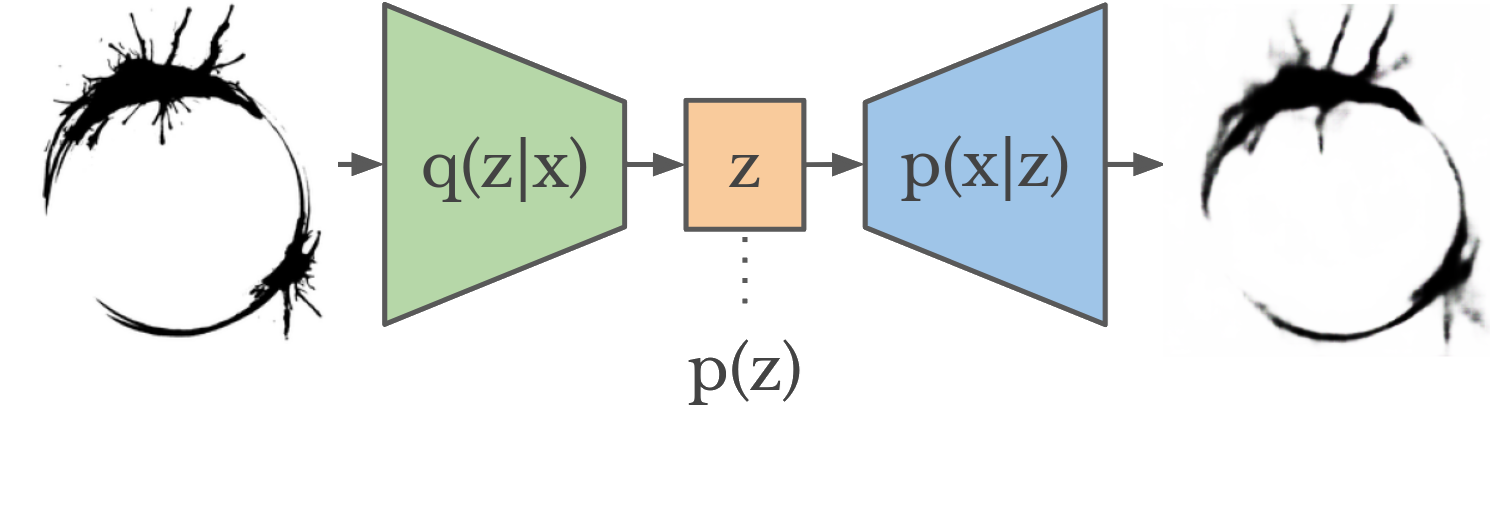

If that is succesfully achieved, that means we have a model that understands the overall structure of the logograms and its morphems, learning how to encode its visual features into the lower dimensional representation and using it to reconstruct the image.

The architecture for the $\beta$-VAE is defined below:

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: Conv layers → flatten → μ, logσ²
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # 112x112
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 56x56
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 28x28
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(256 * 14 * 14, latent_dim)
        self.fc_logvar = nn.Linear(256 * 14 * 14, latent_dim)

        # Decoder: z → fully connected → ConvTranspose
        self.fc_decode = nn.Linear(latent_dim, 256 * 14 * 14)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 14, 14)),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 28x28
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 56x56
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 112x112
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),  # 224x224
            nn.Sigmoid()  # To keep output in [0,1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        decoded = self.decoder(self.fc_decode(z))
        return decoded, mu, logvar

In [5]:
def vae_loss(recon_x, x, mu, logvar):
    beta = 1.0
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_div

The model is trained to minimize the reconstruction loss between the input and the output image. After some experimentation, a latent space of 256 dimensions was found to offer a good balance between representation capacity and reconstruction fidelity. This dimensionality seems to be sufficient to capture meaningful structure in the logograms without leading to overfitting or unnecessary complexity.

In [ ]:
from torch import optim
from tqdm import tqdm

#Load the dataset
loader = DataLoader(dataset, batch_size=100, shuffle=True)

# Training loop
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = ConvVAE(latent_dim=256).to(device) #Train for a latent representation that is 256-dimensional
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(60):
    vae.train()
    total_loss = 0
    for _, img in tqdm(loader): # Gets only the image from the dataset
        img = img.to(device)
        recon, mu, logvar = vae(img)
        loss = vae_loss(recon, img, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader.dataset):.4f}")


In [ ]:
torch.save(vae.state_dict(), "vae_trained_beta4_d1024.pth")

Lets test how the VAE reconstructs an example image, to see if it has successfully learned a meaningful latent representation:

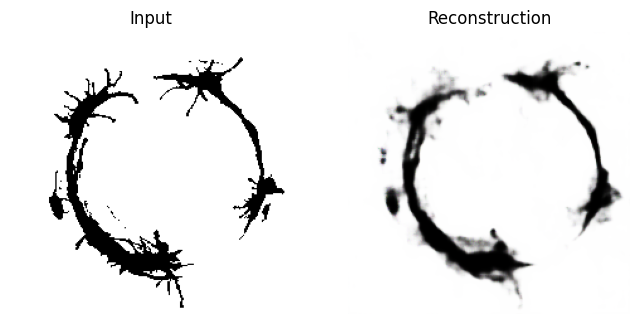

In [7]:
vae.eval()

idx = randint(0, 4900)

img = Image.open(base_dir+f"images/{idx:04d}.png").convert("RGB")
img = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    recon, mu, _ = vae(img)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Input")
show_tensor_image(img)

plt.subplot(1, 2, 2)
plt.title("Reconstruction")
show_tensor_image(recon)

plt.show()

### Loading a pre-trained VAE model

In case you want to skip the training process for the VAE, run the cells below to load the parameters I have trained before.

In [6]:
loader = DataLoader(dataset, batch_size=100, shuffle=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = ConvVAE(latent_dim=256)
vae.load_state_dict(torch.load("/kaggle/input/trained-vae/pytorch/default/1/vae_trained_2.pth", map_location=device))
vae.eval().to(device)  

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=50176, out_features=256, bias=True)
  (fc_logvar): Linear(in_features=50176, out_features=256, bias=True)
  (fc_decode): Linear(in_features=256, out_features=50176, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 14, 14))
    (1): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2

## GRU: Learning how to generate a latent representation from text

By training the VAE, we have a model capable of generating a logogram from its latent representation.

Therefore, we now need a model that converts the text associated to the logogram into that proper latent representation.

The first step is to create a tokenizer for the captions, so that the words in training vocabulary are converted into tokens can be used as inputs for the model. The tokenizer proposed simply learns the vocabulary present in the training captions and transforms this vocabulary into indexes, that are used as tokens.

In [8]:
class Vocab:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = ["<PAD>", "<UNK>"]

    def build(self, sentences):
        for sent in sentences:
            for word in sent.lower().split():
                if word not in self.word2idx:
                    self.word2idx[word] = len(self.idx2word)
                    self.idx2word.append(word)

    def encode(self, sentence):
        return [self.word2idx.get(w, 1) for w in sentence.lower().split()]

    def __len__(self):
        return len(self.idx2word)

In [10]:
vocab = Vocab()
vocab.build([caption for caption,_ in dataset])
print("The vocabulary learned from the data has "+str(len(vocab))+" elements.")

The vocabulary learned from the data has 51 elements.


Then, we need to define a model responsible for "digesting" the tokens of the captions sequentially and producing a final vector with the same dimensions of the latent representation learned by the VAE. The architecture chosen for this is a Gated Recurrent Unit (GRU), a especial type of Recurrent Neural Network (RNN).

The first layer of the model is an Embedding layer, which is responsible for converting the token indexes first into a one-hot encoding and than into a dense embedding representation of dimension `embed_dim`, which is also learned in the training process. 

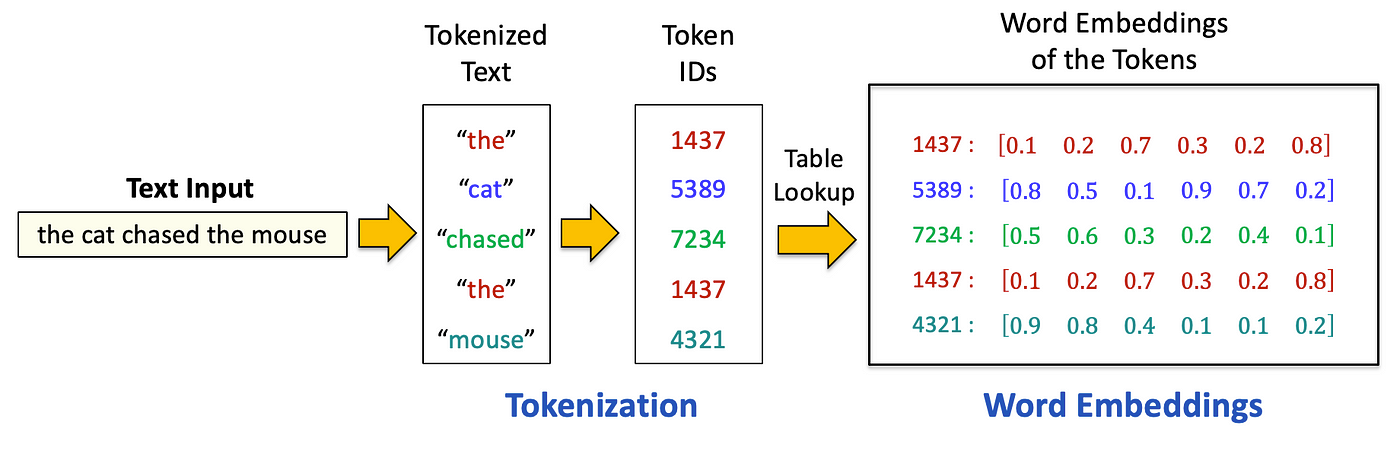

The embeddings of each token are then sequentially fed to the GRU model, which is trained to generate a latent representation.


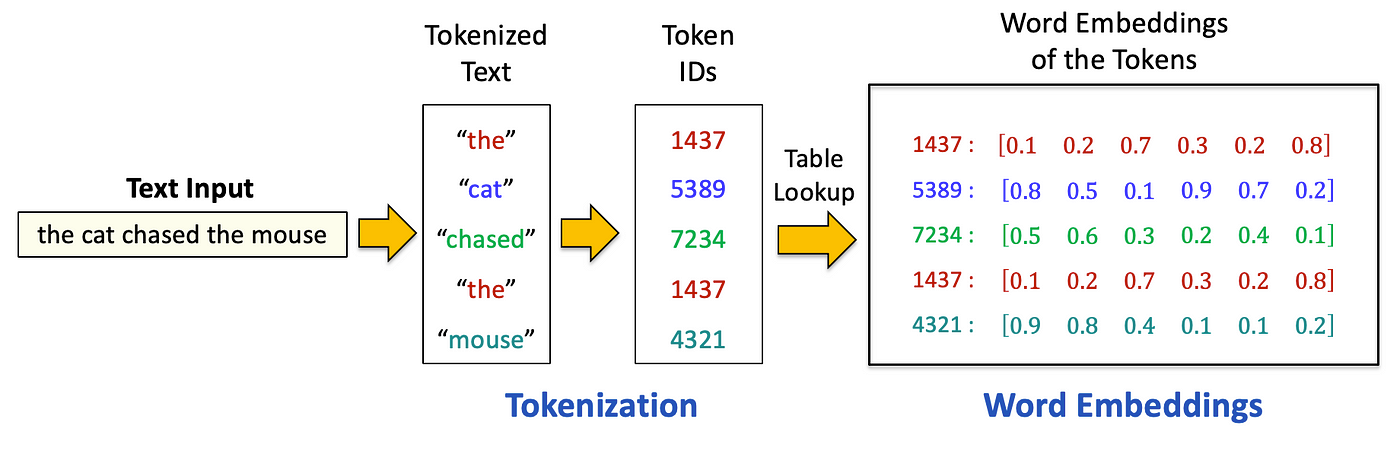

In [11]:
class GRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, latent_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, latent_dim, batch_first=True)
        self.fc = nn.Linear(latent_dim, latent_dim)

    def forward(self, token_ids):
        embedded = self.embed(token_ids)
        _, hidden = self.rnn(embedded)
        return self.fc(hidden.squeeze(0))

In the training loop for the GRU, we use the tokenized sequence for each caption as input and the output latent representation of the corresponded logogram calculated by the encoder part of the VAE as target, since the goal is having the GRU to learn this representation.

In [ ]:
from torch.nn.utils.rnn import pad_sequence

gru = GRU(len(vocab), embed_dim=256, latent_dim=256).to(device) # latent_dim of the output must be the same from the VAE
optimizer = torch.optim.Adam(gru.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training Loop
for epoch in range(30):
    gru.train()
    total_loss = 0
    for captions, images in loader:
        # Tokenize the captions
        token_tensors = [torch.tensor(vocab.encode(c), dtype=torch.long) for c in captions]
        token_batch = pad_sequence(token_tensors, batch_first=True, padding_value=0).to(device)

        images = images.to(device)

        with torch.no_grad():
            _, mu, logvar = vae(images)

        # Compute expected latent representation for the associated logogram
        z_target = mu
        z_pred = gru(token_batch)

        loss = loss_fn(z_pred, z_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader):.4f}")

In [ ]:
torch.save(gru.state_dict(), "gru_trained.pth")

### Loading a pre-trained GRU model

In case you want to skip the training process for the GRU, run the cells below to load the parameters I have trained before.

In [12]:
vocab = Vocab()
vocab.build([caption for caption,_ in dataset])
gru = GRU(len(vocab), embed_dim=256, latent_dim=256).to(device)
gru.load_state_dict(torch.load("/kaggle/input/gru-trained/pytorch/default/1/gru_trained.pth", map_location=device))
gru.eval().to(device)

GRU(
  (embed): Embedding(51, 256)
  (rnn): GRU(256, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=256, bias=True)
)

## Generating a Logogram from Text

Finally, if we concanate the 2 trained models so that:

* A text is fed as input of the GRU and converted into a latent representation
* The latent representation is fed as input of the decoder part of the VAE and used to generate a logogram

We have a complete pipeline for a model that generates logograms from text!


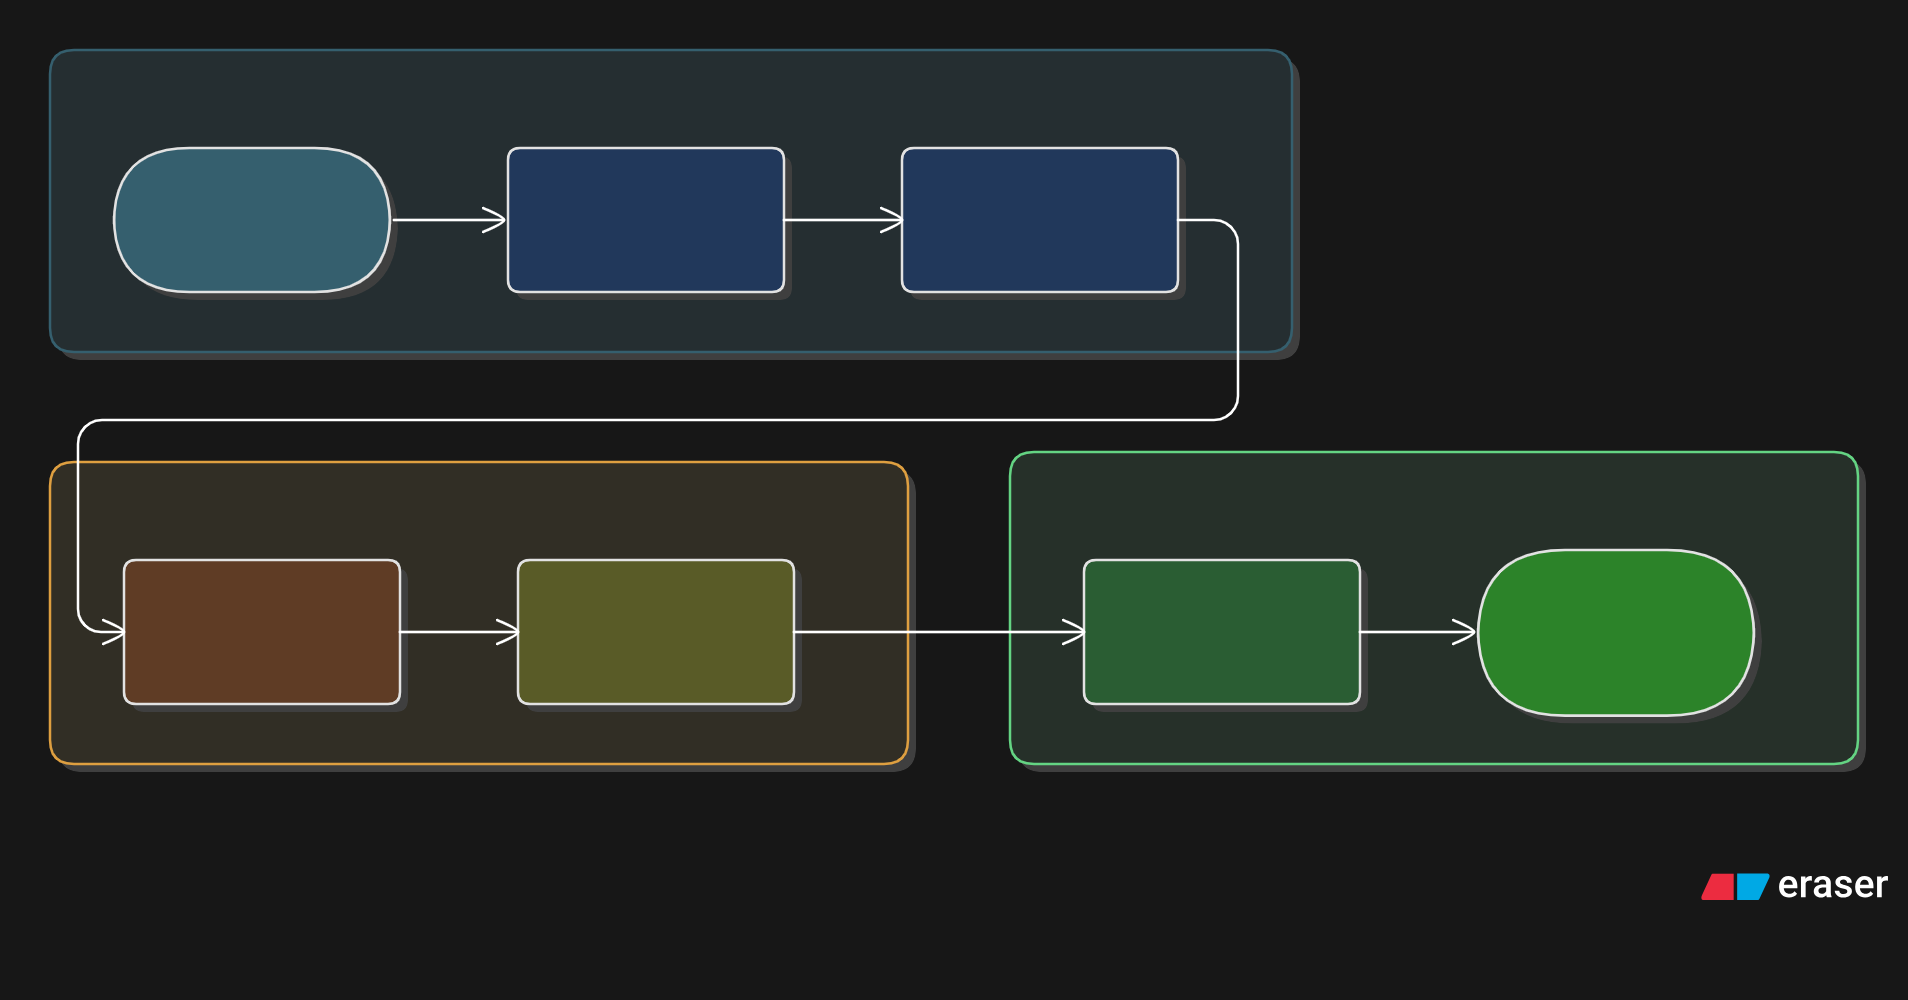

In [13]:
def generate_logogram(text, gru, vae, vocab, device="cpu"):
    gru.eval()
    vae.eval()
    with torch.no_grad():
        #Transform text into token sequence
        token_ids = torch.tensor([vocab.encode(text)], dtype=torch.long).to(device)

        #Compute latent representation using GRU model
        z = gru(token_ids)

        #Generate a new logogram using the VAE-decoder
        img = vae.decoder(vae.fc_decode(z)).squeeze(0).cpu().permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(text)
        plt.axis("off")
        plt.show()

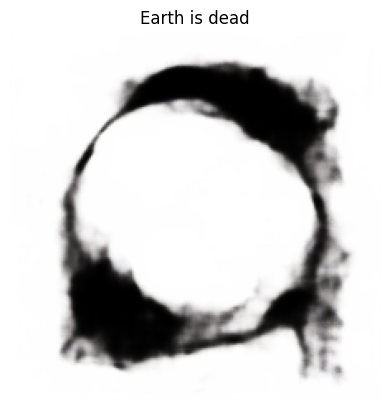

In [14]:
text_to_generate =  "Earth is dead"
generate_logogram(text_to_generate, gru=gru, vae=vae, vocab=vocab, device=device)

## Evaluating the Results

### TODO

## Exploring Latent Space Interpolation and Logogram Morphing

### TODO

## An Attempt for Out-of-Vocabulary (OOV) Generalization

### TODO